# BetaSeg2D Datased loading example

## Requirements



Dataloader depends on the eps-seg codebase, which can be installed with:

```bash
uv pip install git+https://github.com/juglab/eps-Seg.git
``` 

## Data Preparation and Caching

### BetaSeg Dataset structure (How to organize your TIFF files)



Eps-Seg config classes has a class dedicated to the BetaSeg dataset, which is a 2D dataset of synthetic images.

The configuration expect the following directory structure:

```bash
betaseg
├── [   68]  high_c1
│   ├── [ 556M]  high_c1_gt.tif
│   └── [ 343M]  high_c1_source.tif
├── [   68]  high_c2
│   ├── [ 525M]  high_c2_gt.tif
│   └── [ 323M]  high_c2_source.tif
├── [   68]  high_c3
│   ├── [ 557M]  high_c3_gt.tif
│   └── [ 340M]  high_c3_source.tif
└── [   68]  high_c4
    ├── [ 575M]  high_c4_gt.tif
    └── [ 351M]  high_c4_source.tif
```

where "high_c*" are the different stacks of the dataset.


### Caching


The DataModule configuration allows to cache the dataset in a custom directory, which is useful to speed up the loading of the data. It caches:
- Normalized Stacks (source and gt) in .npy format
- Statistics of the training data (mean and std)
- (2D version) Indices of the slices used for training and validation in each fold


Caching is enabled by default, but you need to specify a desired directory for the cache, which needs to be different from the original dataset directory. 

A new subfolder is created for each dataset name, seed and fold (if applicable). For example, if you specify the cache directory as "cache" and you are using the BetaSeg dataset with seed 42 and fold 0, the cache will be stored in "cache/betaseg_2d_dev_seed_42_fold_0/".

Cache is generated automatically upon DataModule initialization. The folder needs to be deleted if you make any change to the source data or the DataModule splitting logic.

## Loading BetaSeg2D

### Dataset configuration


Each dataset is configured with a `eps_seg.config.datasets import BetaSegDatasetConfig` object, which can be populated from yaml files or directly in code.

Currently, if you want to do k-fold cross validation, you need to create a separate configuration for each fold.
An example of yaml configuration for the BetaSeg2D dataset is the following:

```yaml
    type: "BetaSegDatasetConfig" # Points to the class in eps_seg.config.datasets
    dim: 2 # Dimensionality of the returned patches
    name: "betaseg_2d" # Name of the dataset, used for caching.
    fold: 0 # Fold to use with this configuration. 
    max_folds: 5 # Total number of folds for cross-validation (default: 5)
    data_dir: "path_to_your_dataset/betaseg"
    cache_root: "cache/"
    enable_cache: True
    train_keys: ["high_c1", "high_c2", "high_c3"] # Stacks to use for training/validation
    test_keys: ["high_c4"] # Stacks to use for testing
    seed: 42 # Seed for reproducibility of the splits/shuffling
    patch_size: 64 # Size of the returned patches
    samples_per_class_training: {0: 1, 1: 2, 2: 1, 3: 1} # Number of samples per class for training. Used to balance the classes and data amount in the training set. 
    samples_per_class_validation: {0: 2, 1: 4, 2: 2, 3: 2} # Number of samples per class for validation. Used to balance the classes and data amount in the validation set.
```

Currently, the dataloader also need a TrainConfig object to be initialized. This is used to set the batch size and the number of batches per epoch (which is used to make experiments with different data amounts comparable). 
If you plan to use eps-Seg, please refer to the documentation for more details on the TrainConfig and how to set it up.

Otherwise, you can just create a dummy TrainConfig object with the desired batch size and number of batches per epoch.

### Loading DataModule

In [ ]:
from eps_seg.dataloaders.datamodules import EPSSegDataModule
from eps_seg.config.datasets import BetaSegDatasetConfig
from eps_seg.config.train import TrainConfig

# You can load a dataset configuration from a YAML file using the `from_yaml` method of the dataset config class. For example:
dataset_config = BetaSegDatasetConfig.from_yaml("betaseg_2d_example_fold0.yaml")
dm = EPSSegDataModule(dataset_config, 
                      train_cfg= TrainConfig(model_name="betaseg_2d_example",
                                             batch_size=512,
                                             batches_per_pseudoepoch=100)
                    )

### If you use PyTorch Lightning
just pass dm to the `fit` method of your trainer.

### If you use bare PyTorch
You can manually call the function to generate data and load the dataset splits as follows:

In [5]:
dm.prepare_data() # This will check cache directory for preprocessed data, and generate it if not found. It will also load the train/val/test splits and store them in the datamodule object.
# To internally load dataloaders and dataset, you can call the `setup` method for each stage you need
dm.setup("fit") # this will make training/validation dataloaders available
dm.setup("test") # this will make test dataloader available

Checking cache directory at /group/jug/edoardo/projects/eps-Seg/scripts/dev/k_fold_dev/dev_cache/betaseg_2d_dev_seed_42_fold_0...
Cache directory is valid. Skipping caching.
Setting up data for stage: fit...
Loaded cached data statistics from /group/jug/edoardo/projects/eps-Seg/scripts/dev/k_fold_dev/dev_cache/betaseg_2d_dev_seed_42_fold_0.
Loaded cached train/validation dataset splits from /group/jug/edoardo/projects/eps-Seg/scripts/dev/k_fold_dev/dev_cache/betaseg_2d_dev_seed_42_fold_0 (fold: 0).
  Class 0 (anchors): 2434 samples
  Class 1 (anchors): 2320 samples
  Class 2 (anchors): 2371 samples
  Class 3 (anchors): 2324 samples
  Class 0 (neighbors): 20224 samples
  Class 1 (neighbors): 16020 samples
  Class 2 (neighbors): 15253 samples
  Class 3 (neighbors): 14646 samples
  Class 0 (anchors): 1213 samples
  Class 1 (anchors): 1171 samples
  Class 2 (anchors): 1192 samples
  Class 3 (anchors): 1158 samples
  Class 0 (neighbors): 10942 samples
  Class 1 (neighbors): 8034 samples
  C

To access the Torch dataloader, you can call the following methods:

In [7]:
train_dataloader = dm.train_dataloader()
val_dataloader = dm.val_dataloader()

## Data description

Our dataset can be configured with different parameters.
In the data_preparation step, we splitted the stacks into training and validation based on the slice (z-axis) indices, being it a 2D dataset. 

The training dataset can work in two modes:
- "supervised"
- "semisupervised"

In both modes, you get the following batch of data from the dataloader:

In [15]:
for (patches, labels, segments, coords) in train_dataloader:
    break

where:
 - `patches` [B, C, patch_size, patch_size]: batch of image patches
 - `labels` [B]: batch of labels for *CENTER PIXEL* of the patch (class indices)
 - `segments` [B, C, patch_size, patch_size]: batch of segmentation masks for the patches. Labels -1 is for unlabelled pixels.
 - `coords` [B, 3]: batch of coordinates of the center pixel of the patch in the original stack (z, y, x)

NOTICE:

Since patches are assumed to have even dimensions, the center pixel are located at (patch_size//2 - 1, patch_size//2 - 1) of the patch, 
which means that for a patch size of 64, the returned label will have indices (31, 31) of the patch.

### Supervised mode (Default)

In Supervised mode, you get only labelled voxels as patches:

In [40]:
train_dataloader.dataset.set_mode("supervised")
for (patches, labels, segments, coords) in train_dataloader:
    break

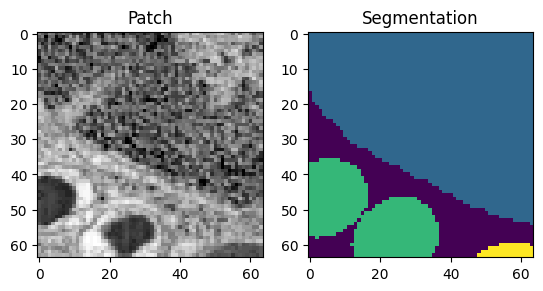

Label of center pixel (31, 31): 1
Coordinates (z, y, x): [805 238 490]


In [43]:
import matplotlib.pyplot as plt
import numpy as np
idx = 32

plt.subplot(1, 2, 1)
plt.imshow(patches[idx, 0].numpy(), cmap="gray")
plt.title("Patch")

plt.subplot(1, 2, 2)
plt.imshow(segments[idx, 0].numpy(), cmap="viridis")
plt.title("Segmentation")
plt.show()

print("Label of center pixel (31, 31):", labels[idx].item())
print("Coordinates (z, y, x):", coords[0].numpy())


### Semi-supervised mode

In semisupervised mode, for training only, you get a different batch of data, which includes both labelled and unlabelled pixels as center of the patches.

In this mode, there are two main differences:
1. The returned labelled patches are interleaved with `dataset_config.n_neighbors` unlabelled patches.
2. The returned `coords` are folded by `dataset_config.n_neighbors + 1`, which means that its shape will be now [B, n_neighbors + 1, 3].

This means that you get:

SB = B x (1 + n_neighbors)

 - `patches` [SB, C, patch_size, patch_size]: batch of image patches
 - `labels` [SB]: batch of labels for *CENTER PIXEL* of the patch (class indices). For unlabelled pixels, the label is -1.
 - `segments` [SB, C, patch_size, patch_size]: batch of segmentation masks for the patches. Labels -1 is for unlabelled pixels.
 - `coords` [B, n_neighbors + 1, 3]: batch of coordinates of the center pixel of the patch in the original stack (z, y, x)

Please refer to the paper for how these patches are sampled and used for training.

First 16 labels in the batch: tensor([ 0, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1])


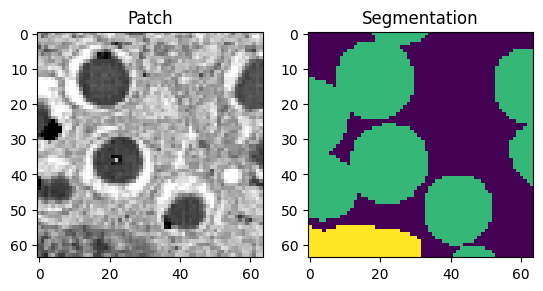

Label of center pixel (31, 31): 2
Coordinates of Labelled voxel and 7 Neighbors (z, y, x):
[274 353 669]
[274 355 670]
[274 351 670]
[274 354 670]
[274 355 668]
[274 354 671]
[274 352 670]
[274 352 668]


In [58]:
train_dataloader.dataset.set_mode("semisupervised")
for (patches, labels, segments, coords) in train_dataloader:
    break

print("First 16 labels in the batch:", labels[:16])
# Please notice as the known labels are interleaved with -1 (unlabelled pixels)

plt.subplot(1, 2, 1)
plt.imshow(patches[idx, 0].numpy(), cmap="gray")
plt.title("Patch")

plt.subplot(1, 2, 2)
plt.imshow(segments[idx, 0].numpy(), cmap="viridis")
plt.title("Segmentation")
plt.show()

print("Label of center pixel (31, 31):", labels[idx].item())
print("Coordinates of Labelled voxel and 7 Neighbors (z, y, x):")
for neigh_coord in coords[idx].numpy():
    print(neigh_coord)

### Semi-supervised mode parameters

The unlabeled patches are sampled whithin a given radius around the labelled pixel, which is initially set to `TrainConfig.initial_radius`, but it can be updated during training using:

```python
train_dataloader.dataset.set_radius(new_radius)
```
